# Coordinate Sensitivity Analysis for Hierarchical Regression Ordering

This notebook determines the **optimal coordinate prediction order** (e.g. X→Y→Z vs Y→X→Z vs ...) for the hierarchical autoregressive regression head.

**Rationale**: In the GPS-HiCoR architecture, each successive coordinate is conditioned on previous predictions via FiLM. The coordinate that is *easiest* to predict independently should go **first** (it doesn't need conditioning), and the *hardest* should go **last** (it benefits most from conditioning on the others).

## Analyses performed
1. **Target statistics** — variance, range, entropy per coordinate
2. **Feature-target mutual information** — how much each node-level feature distribution tells us about each coordinate
3. **Inter-coordinate correlation** — quantify dependencies between X, Y, Z
4. **Single-coordinate MLP probes** — train tiny MLPs to predict each coordinate independently from the graph readout and compare test MAE
5. **Summary & recommended ordering**

In [1]:
import sys
from pathlib import Path

# Ensure project root is on the path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

DATASET_PATH = PROJECT_ROOT / "datasets" / "E_10.0MeV_K_4"
print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset path : {DATASET_PATH}")

Project root : c:\Users\victo\Desktop\dune-gnn
Dataset path : c:\Users\victo\Desktop\dune-gnn\datasets\E_10.0MeV_K_4


In [2]:
import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", font_scale=1.2)
COORD_NAMES = ["X", "Y", "Z"]

c:\Users\victo\miniconda3\envs\Deep\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Dataset

In [3]:
# Load pre-built dataset artifacts
metadata_path = DATASET_PATH / "dataset_metadata.pkl"
target_path   = DATASET_PATH / "target.pkl"

with open(metadata_path, "rb") as f:
    metadata = pickle.load(f)

with open(target_path, "rb") as f:
    target_df = pickle.load(f)

# Load all graph chunks
graphs = []
for chunk_idx in tqdm(range(metadata["num_chunks"]), desc="Loading chunks"):
    chunk_path = DATASET_PATH / "chunks" / f"dataset_chunk_{chunk_idx}.pt"
    chunk = torch.load(chunk_path, weights_only=False)
    graphs.extend(chunk)

print(f"Loaded {len(graphs)} graphs")
print(f"Target shape: {target_df.shape}")
print(f"Target columns: {list(target_df.columns)}")

Loading chunks: 100%|██████████| 10/10 [00:04<00:00,  2.13it/s]

Loaded 1000 graphs
Target shape: (1000, 3)
Target columns: ['event_x', 'event_y', 'event_z']


In [7]:
# Extract raw target matrix (N, 3)
from core.config import config
coord_cols = list(config.data.coordinate_columns)
targets = target_df[coord_cols].to_numpy(dtype=np.float32)

print(f"Coordinate columns: {coord_cols}")
print(f"Targets shape: {targets.shape}")
print(f"\nPer-coordinate statistics (raw):")

Coordinate columns: ['event_x', 'event_y', 'event_z']
Targets shape: (1000, 3)

Per-coordinate statistics (raw):


In [8]:
from scipy.stats import entropy as sp_entropy

# Measure intrinsic difficulty via variance, coefficient of variation, and histogram entropy
difficulty_stats = {}

for i, name in enumerate(COORD_NAMES):
    col = targets[:, i]
    std = col.std()
    var = col.var()
    cv  = std / (np.abs(col.mean()) + 1e-8)   # coefficient of variation
    
    # Differential entropy proxy via histogram
    hist_counts, _ = np.histogram(col, bins=50, density=True)
    hist_counts = hist_counts[hist_counts > 0]
    h_entropy = sp_entropy(hist_counts)
    
    difficulty_stats[name] = {
        "variance": var,
        "std": std,
        "cv": cv,
        "histogram_entropy": h_entropy,
        "range": np.ptp(col),
    }

import pandas as pd
stats_df = pd.DataFrame(difficulty_stats).T
stats_df = stats_df.round(4)
print("Target difficulty indicators (higher entropy/variance = harder to predict):")
stats_df

Target difficulty indicators (higher entropy/variance = harder to predict):


,variance,std,cv,histogram_entropy,range
X,0.0428,0.2068,0.5295,0.5256,0.50
Y,3.6620,1.9136,0.7638,2.5126,5.95
Z,74.3517,8.6227,0.5831,3.8624,29.50


## 3. Inter-Coordinate Correlation Analysis

Pearson Correlation Matrix:


,X,Y,Z
X,1.0000,0.4886,-0.0120
Y,0.4886,1.0000,-0.0029
Z,-0.0120,-0.0029,1.0000



Spearman Correlation Matrix:


,X,Y,Z
X,1.0000,0.5024,-0.0119
Y,0.5024,1.0000,-0.0024
Z,-0.0119,-0.0024,1.0000


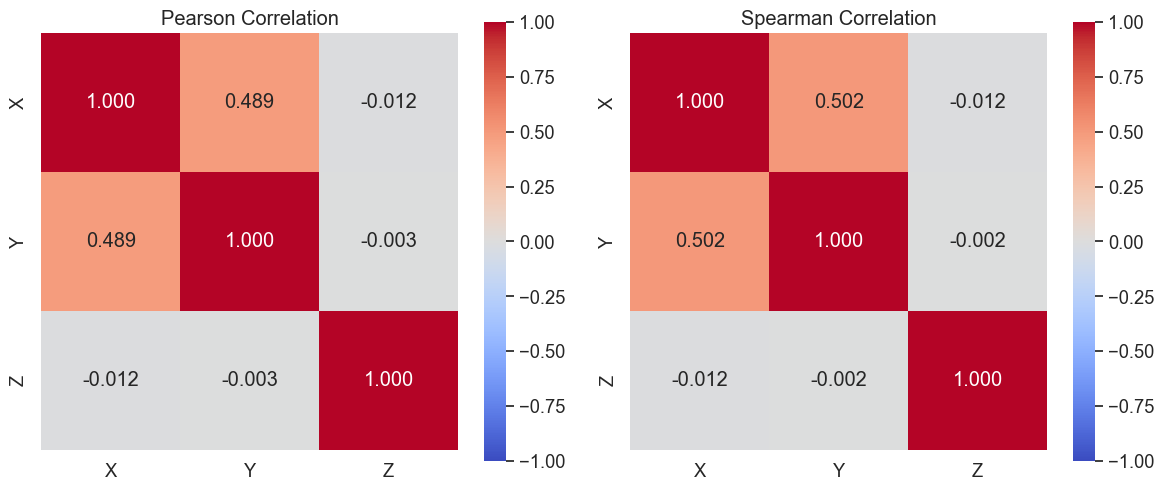

In [9]:
corr_df = pd.DataFrame(targets, columns=COORD_NAMES)

# Pearson correlation
pearson_corr = corr_df.corr(method="pearson")
print("Pearson Correlation Matrix:")
display(pearson_corr.round(4))

# Spearman (rank) correlation – captures nonlinear relationships
spearman_corr = corr_df.corr(method="spearman")
print("\nSpearman Correlation Matrix:")
display(spearman_corr.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(pearson_corr, annot=True, fmt=".3f", cmap="coolwarm", ax=axes[0], vmin=-1, vmax=1, square=True)
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_corr, annot=True, fmt=".3f", cmap="coolwarm", ax=axes[1], vmin=-1, vmax=1, square=True)
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()

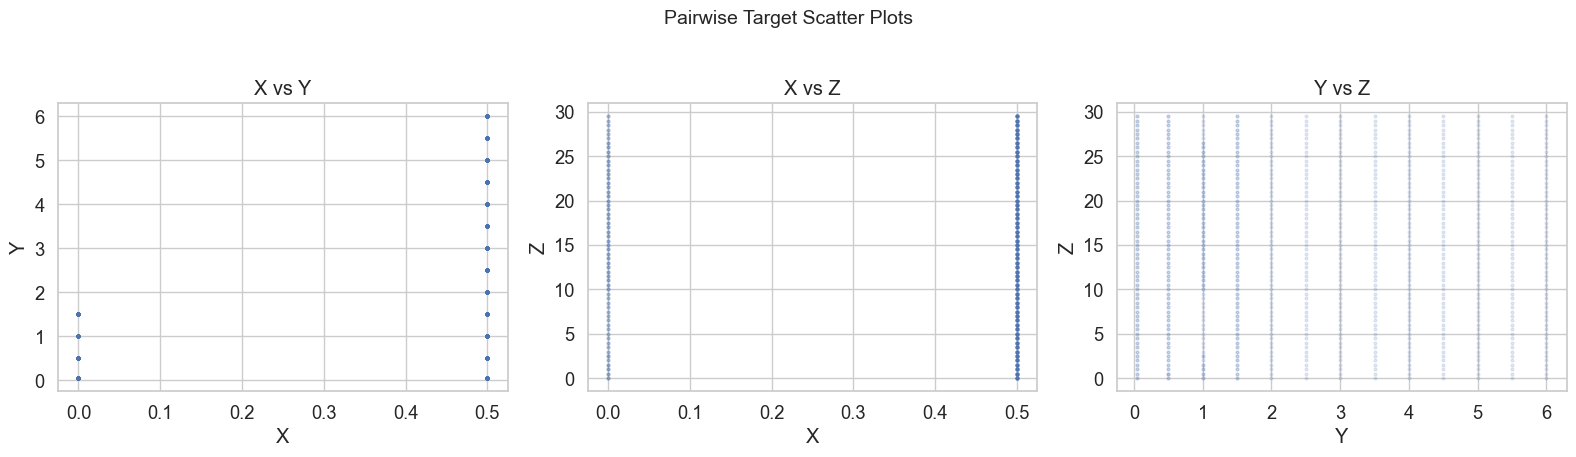

In [10]:
# Pairwise scatter plots to visually inspect dependencies
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, ni, nj) in zip(axes, pairs):
    ax.scatter(targets[:, i], targets[:, j], alpha=0.15, s=4, rasterized=True)
    ax.set_xlabel(ni)
    ax.set_ylabel(nj)
    ax.set_title(f"{ni} vs {nj}")

plt.suptitle("Pairwise Target Scatter Plots", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature–Target Mutual Information

Estimate how much information the **aggregated graph features** (mean of node features per graph) carry about each target coordinate. Higher MI = sensor readings are more informative for that coordinate → easier to predict.

In [11]:
from sklearn.feature_selection import mutual_info_regression

# Build graph-level feature matrix (mean pooling over nodes as a simple summary)
print("Aggregating node features per graph (mean pooling)...")
graph_features = []
for g in tqdm(graphs, desc="Aggregating"):
    feat = g.x.numpy().mean(axis=0)   # mean over nodes
    graph_features.append(feat)

X_feat = np.array(graph_features, dtype=np.float32)
print(f"Graph-level feature matrix: {X_feat.shape}  (n_graphs, n_features)")

Aggregating node features per graph (mean pooling)...


Aggregating: 100%|██████████| 1000/1000 [00:00<00:00, 14703.70it/s]

Graph-level feature matrix: (1000, 4)  (n_graphs, n_features)


In [12]:
# Mutual Information: features → each coordinate
mi_scores = {}
for i, name in enumerate(COORD_NAMES):
    mi = mutual_info_regression(X_feat, targets[:, i], n_neighbors=5, random_state=42)
    mi_scores[name] = {
        "total_MI": mi.sum(),
        "mean_MI":  mi.mean(),
        "max_MI":   mi.max(),
    }
    print(f"{name}: total MI = {mi.sum():.4f}, mean MI = {mi.mean():.4f}, max MI = {mi.max():.4f}")

mi_df = pd.DataFrame(mi_scores).T.round(4)
mi_df

X: total MI = 0.0000, mean MI = 0.0000, max MI = 0.0000
Y: total MI = 0.1047, mean MI = 0.0262, max MI = 0.0870
Z: total MI = 0.2453, mean MI = 0.0613, max MI = 0.1454


,total_MI,mean_MI,max_MI
X,0.0000,0.0000,0.0000
Y,0.1047,0.0262,0.0870
Z,0.2453,0.0613,0.1454


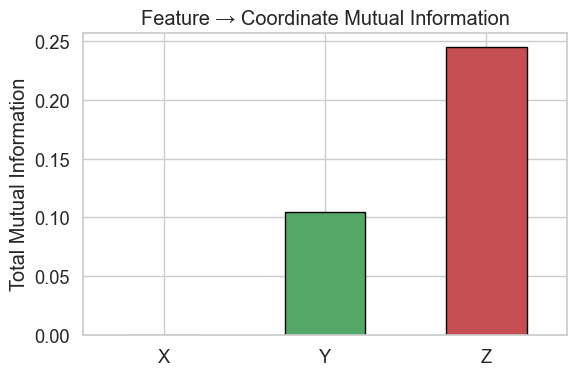

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
mi_df["total_MI"].plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"], edgecolor="black")
ax.set_ylabel("Total Mutual Information")
ax.set_title("Feature → Coordinate Mutual Information")
ax.set_xticklabels(COORD_NAMES, rotation=0)
plt.tight_layout()
plt.show()

## 5. Single-Coordinate MLP Probes

Train a small MLP to independently predict each coordinate from mean-pooled graph features.
The coordinate with **lowest test MAE** is easiest → should be predicted first.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim

# Normalise features and targets
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, targets, test_size=0.15, random_state=42
)

feat_scaler   = StandardScaler().fit(X_train)
target_scaler = StandardScaler().fit(y_train)

X_train_s = feat_scaler.transform(X_train)
X_test_s  = feat_scaler.transform(X_test)
y_train_s = target_scaler.transform(y_train)
y_test_s  = target_scaler.transform(y_test)

print(f"Train: {X_train_s.shape[0]} samples | Test: {X_test_s.shape[0]} samples")

Train: 850 samples | Test: 150 samples


In [15]:
class CoordProbe(nn.Module):
    """Tiny MLP for single-coordinate regression."""
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden // 2),
            nn.LayerNorm(hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, 1),
        )
    def forward(self, x):
        return self.net(x)


def train_probe(coord_idx, X_tr, y_tr, X_te, y_te, epochs=300, lr=1e-3):
    """Train a probe for one coordinate and return test MAE (in original scale)."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    in_dim = X_tr.shape[1]
    
    model = CoordProbe(in_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_tr[:, coord_idx:coord_idx+1], dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=device)
    y_te_t = torch.tensor(y_te[:, coord_idx:coord_idx+1], dtype=torch.float32, device=device)
    
    losses = []
    for epoch in range(epochs):
        model.train()
        pred = model(X_tr_t)
        loss = nn.functional.mse_loss(pred, y_tr_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        pred_test = model(X_te_t).cpu().numpy()
    
    # Denormalize predictions and targets
    mean_c = target_scaler.mean_[coord_idx]
    std_c  = target_scaler.scale_[coord_idx]
    pred_orig   = pred_test * std_c + mean_c
    target_orig = y_te[:, coord_idx:coord_idx+1] * std_c + mean_c
    
    mae  = np.abs(pred_orig - target_orig).mean()
    rmse = np.sqrt(((pred_orig - target_orig) ** 2).mean())
    
    return mae, rmse, losses

print("Training single-coordinate probes...")
probe_results = {}
probe_losses  = {}
for i, name in enumerate(COORD_NAMES):
    mae, rmse, losses = train_probe(i, X_train_s, y_train_s, X_test_s, y_test_s)
    probe_results[name] = {"MAE": mae, "RMSE": rmse}
    probe_losses[name] = losses
    print(f"  {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}")

probe_df = pd.DataFrame(probe_results).T.round(4)
probe_df

Training single-coordinate probes...
  X: MAE = 0.1751, RMSE = 0.2122
  Y: MAE = 1.7013, RMSE = 1.9301
  Z: MAE = 7.4668, RMSE = 8.6543


,MAE,RMSE
X,0.1751,0.2122
Y,1.7013,1.9301
Z,7.4668,8.6543


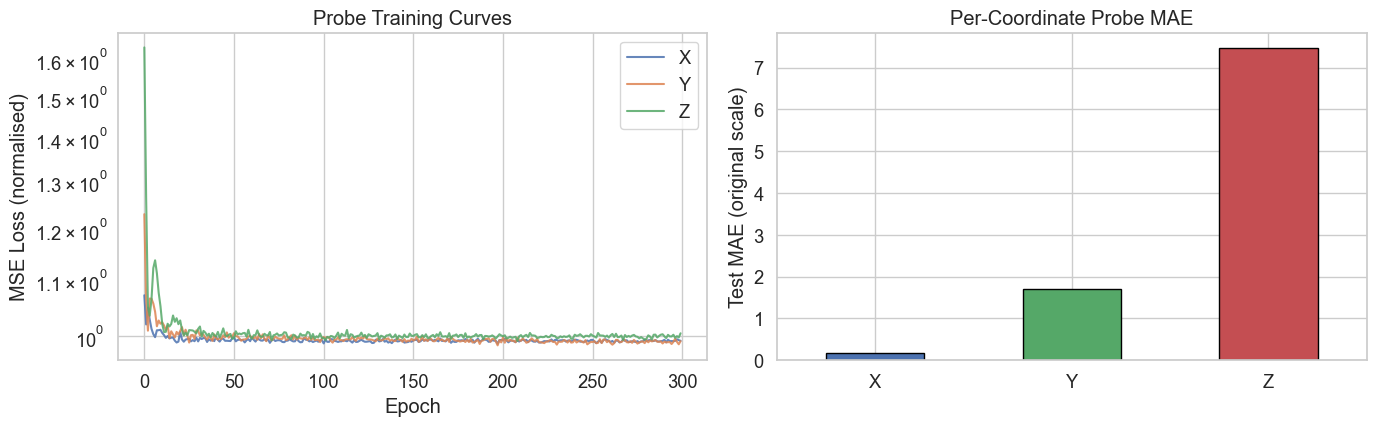

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Training loss curves
ax = axes[0]
for name, losses in probe_losses.items():
    ax.plot(losses, label=name, alpha=0.85)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (normalised)")
ax.set_title("Probe Training Curves")
ax.legend()
ax.set_yscale("log")

# Bar chart of test MAE
ax = axes[1]
colors = ["#4C72B0", "#55A868", "#C44E52"]
probe_df["MAE"].plot(kind="bar", ax=ax, color=colors, edgecolor="black")
ax.set_ylabel("Test MAE (original scale)")
ax.set_title("Per-Coordinate Probe MAE")
ax.set_xticklabels(COORD_NAMES, rotation=0)

plt.tight_layout()
plt.show()

## 6. Conditional Improvement Analysis

For each ordered pair (A, B), train a probe that predicts B given features **+ ground-truth A**. If knowing A significantly helps predict B, then A should come before B in the hierarchy.

In [17]:
def train_conditional_probe(target_idx, cond_indices, X_tr, y_tr, X_te, y_te, epochs=300):
    """
    Predict coordinate `target_idx` given features + ground-truth of `cond_indices`.
    Returns test MAE in original scale.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Augment features with conditioning coordinates
    X_tr_aug = np.hstack([X_tr, y_tr[:, cond_indices]])
    X_te_aug = np.hstack([X_te, y_te[:, cond_indices]])
    
    in_dim = X_tr_aug.shape[1]
    model = CoordProbe(in_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    X_tr_t = torch.tensor(X_tr_aug, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_tr[:, target_idx:target_idx+1], dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_te_aug, dtype=torch.float32, device=device)
    
    for epoch in range(epochs):
        model.train()
        pred = model(X_tr_t)
        loss = nn.functional.mse_loss(pred, y_tr_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
    
    model.eval()
    with torch.no_grad():
        pred_test = model(X_te_t).cpu().numpy()
    
    mean_c = target_scaler.mean_[target_idx]
    std_c  = target_scaler.scale_[target_idx]
    pred_orig   = pred_test * std_c + mean_c
    target_orig = y_te[:, target_idx:target_idx+1] * std_c + mean_c
    
    return float(np.abs(pred_orig - target_orig).mean())


# For each permutation, simulate the hierarchical chain:
# - 1st coord: predicted from features alone
# - 2nd coord: predicted from features + GT of 1st
# - 3rd coord: predicted from features + GT of 1st & 2nd

print("Evaluating all 6 coordinate orderings...\n")

ordering_results = {}
for perm in permutations(range(3)):
    perm_name = "→".join(COORD_NAMES[i] for i in perm)
    
    # 1st: unconditional
    mae_1 = probe_results[COORD_NAMES[perm[0]]]["MAE"]
    
    # 2nd: conditioned on 1st
    mae_2 = train_conditional_probe(perm[1], [perm[0]], X_train_s, y_train_s, X_test_s, y_test_s)
    
    # 3rd: conditioned on 1st & 2nd
    mae_3 = train_conditional_probe(perm[2], [perm[0], perm[1]], X_train_s, y_train_s, X_test_s, y_test_s)
    
    total_mae = mae_1 + mae_2 + mae_3
    ordering_results[perm_name] = {
        f"{COORD_NAMES[perm[0]]} (1st, uncond)": round(mae_1, 4),
        f"{COORD_NAMES[perm[1]]} (2nd, cond 1)": round(mae_2, 4),
        f"{COORD_NAMES[perm[2]]} (3rd, cond 2)": round(mae_3, 4),
        "Total MAE": round(total_mae, 4),
    }
    print(f"  {perm_name}: 1st={mae_1:.4f}  2nd={mae_2:.4f}  3rd={mae_3:.4f}  total={total_mae:.4f}")

ordering_df = pd.DataFrame(ordering_results).T
ordering_df = ordering_df.sort_values("Total MAE")
ordering_df

Evaluating all 6 coordinate orderings...

  X→Y→Z: 1st=0.1751  2nd=1.3677  3rd=7.4813  total=9.0241
  X→Z→Y: 1st=0.1751  2nd=7.4788  3rd=1.4033  total=9.0572
  Y→X→Z: 1st=1.7013  2nd=0.1194  3rd=7.4614  total=9.2821
  Y→Z→X: 1st=1.7013  2nd=7.4251  3rd=0.1163  total=9.2427
  Z→X→Y: 1st=7.4668  2nd=0.1730  3rd=1.3981  total=9.0378
  Z→Y→X: 1st=7.4668  2nd=1.7087  3rd=0.1234  total=9.2988


,"X (1st, uncond)","Y (2nd, cond 1)","Z (3rd, cond 2)",Total MAE,"Z (2nd, cond 1)","Y (3rd, cond 2)","Y (1st, uncond)","X (2nd, cond 1)","X (3rd, cond 2)","Z (1st, uncond)"
X→Y→Z,0.1751,1.3677,7.4813,9.0241,NaN,NaN,NaN,NaN,NaN,NaN
Z→X→Y,NaN,NaN,NaN,9.0378,NaN,1.3981,NaN,0.1730,NaN,7.4668
X→Z→Y,0.1751,NaN,NaN,9.0572,7.4788,1.4033,NaN,NaN,NaN,NaN
Y→Z→X,NaN,NaN,NaN,9.2427,7.4251,NaN,1.7013,NaN,0.1163,NaN
Y→X→Z,NaN,NaN,7.4614,9.2821,NaN,NaN,1.7013,0.1194,NaN,NaN
Z→Y→X,NaN,1.7087,NaN,9.2988,NaN,NaN,NaN,NaN,0.1234,7.4668


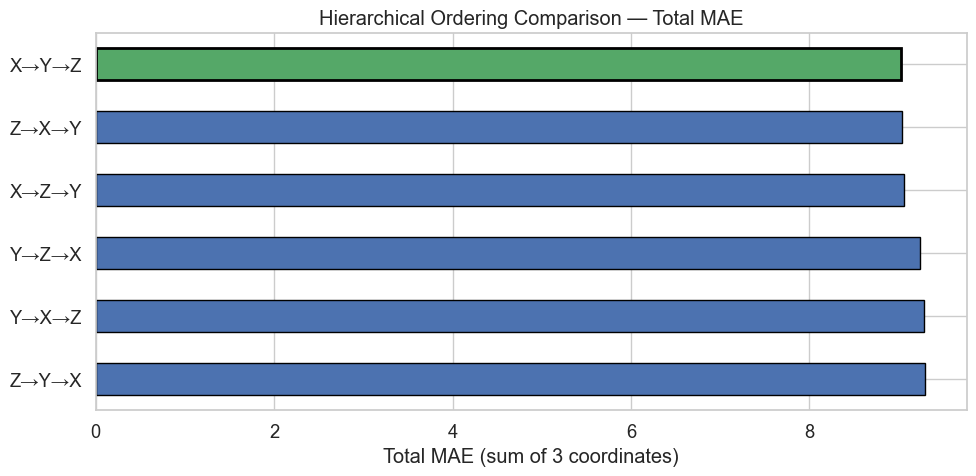

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ordering_df["Total MAE"].plot(
    kind="barh", ax=ax, color="#4C72B0", edgecolor="black"
)
ax.set_xlabel("Total MAE (sum of 3 coordinates)")
ax.set_title("Hierarchical Ordering Comparison — Total MAE")
ax.invert_yaxis()

# Highlight best
best_idx = ordering_df["Total MAE"].idxmin()
bars = ax.patches
for bar, label in zip(bars, ordering_df.index):
    if label == best_idx:
        bar.set_color("#55A868")
        bar.set_edgecolor("black")
        bar.set_linewidth(2)

plt.tight_layout()
plt.show()

## 7. Summary & Recommendation

In [19]:
print("=" * 65)
print("        COORDINATE ORDERING ANALYSIS — SUMMARY")
print("=" * 65)

# --- A. Intrinsic difficulty ranking ---
print("\n[A] Intrinsic Difficulty (independent probe MAE, lower = easier):")
sorted_probes = sorted(probe_results.items(), key=lambda x: x[1]["MAE"])
for rank, (name, res) in enumerate(sorted_probes, 1):
    print(f"    {rank}. {name}  MAE = {res['MAE']:.4f}")

# --- B. Information content ranking ---
print("\n[B] Feature → Target Mutual Information (higher = more informative):")
sorted_mi = sorted(mi_scores.items(), key=lambda x: x[1]["total_MI"], reverse=True)
for rank, (name, res) in enumerate(sorted_mi, 1):
    print(f"    {rank}. {name}  total MI = {res['total_MI']:.4f}")

# --- C. Best hierarchical ordering ---
best_order = ordering_df.index[0]
best_total = ordering_df.iloc[0]["Total MAE"]
worst_order = ordering_df.index[-1]
worst_total = ordering_df.iloc[-1]["Total MAE"]

print(f"\n[C] Best Hierarchical Ordering:  {best_order}  (total MAE = {best_total:.4f})")
print(f"    Worst Ordering:              {worst_order}  (total MAE = {worst_total:.4f})")
print(f"    Improvement:                 {((worst_total - best_total) / worst_total * 100):.1f}% reduction in total MAE")

print("\n" + "=" * 65)
print(f">>> RECOMMENDED PREDICTION ORDER:  {best_order}")
print("=" * 65)

# Map back to coordinate indices for use in model config
order_names = best_order.split("→")
order_indices = [COORD_NAMES.index(n) for n in order_names]
print(f"\nTo configure in model: coord_order = {order_indices}  # {order_names}")

        COORDINATE ORDERING ANALYSIS — SUMMARY

[A] Intrinsic Difficulty (independent probe MAE, lower = easier):
    1. X  MAE = 0.1751
    2. Y  MAE = 1.7013
    3. Z  MAE = 7.4668

[B] Feature → Target Mutual Information (higher = more informative):
    1. Z  total MI = 0.2453
    2. Y  total MI = 0.1047
    3. X  total MI = 0.0000

[C] Best Hierarchical Ordering:  X→Y→Z  (total MAE = 9.0241)
    Worst Ordering:              Z→Y→X  (total MAE = 9.2988)
    Improvement:                 3.0% reduction in total MAE

>>> RECOMMENDED PREDICTION ORDER:  X→Y→Z

To configure in model: coord_order = [0, 1, 2]  # ['X', 'Y', 'Z']
